In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

T = 1.0, m_lim = 0.9992757519570612
T = 2.0, m_lim = 0.911319377877496
T = 2.5, m_lim = 0
T = 4.0, m_lim = 0


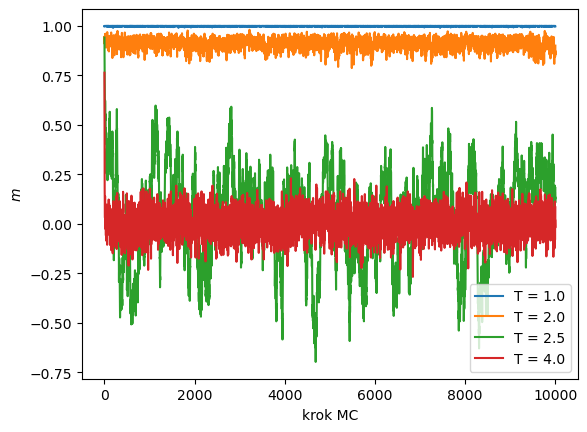

In [3]:
dane_gestosc_nam_zadanie1 = np.loadtxt('g_nam_zad1.dat')
T = [1.0, 2.0, 2.5, 4.0]

def m_graniczne(T: float):

    val = 1 - np.sinh(2/T)**(-4)
    return (val**(1/8)) if val > 0 else 0

for idx, dane in enumerate(dane_gestosc_nam_zadanie1):
    plt.plot(dane[:10000], label = f"T = {T[idx]}")
    print( f"T = {T[idx]}, m_lim = {m_graniczne(T[idx])}")

plt.xlabel("krok MC")
plt.ylabel(r"$m$")
plt.legend()
plt.show()

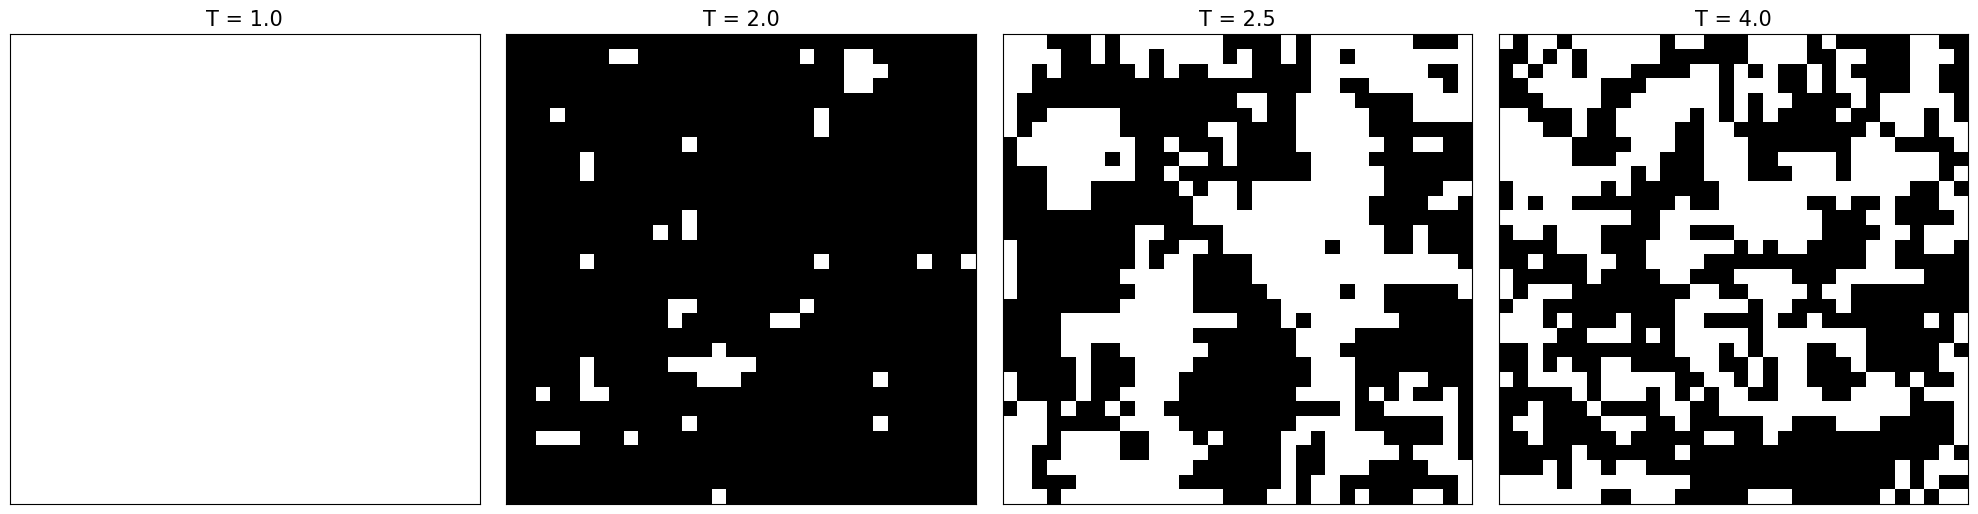

In [4]:
dane_mapa_zadanie1 = np.loadtxt('mapa_zad1.dat').transpose()
dane_mapa = [dane for dane in np.split(dane_mapa_zadanie1[2],4)]
dane_x = np.split(dane_mapa_zadanie1[0], 4)[0]
dane_y = np.split(dane_mapa_zadanie1[1], 4)[0]

T = [1.0, 2.0, 2.5, 4.0]
cmap = ListedColormap(['white', 'black'])

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, ax in enumerate(axes):
    Z = dane_mapa[i].reshape((int(dane_y.max() + 1), int(dane_x.max() + 1)))
    pcm = ax.pcolormesh(dane_x.reshape(Z.shape), dane_y.reshape(Z.shape), Z, shading='auto', cmap=cmap)
    ax.set_title(f'T = {T[i]}', fontsize = 15)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])

#fig.suptitle("W ostatnim kroku MC mapy stan uprzejmie zapisany", fontsize = 20)

plt.tight_layout()
plt.show()

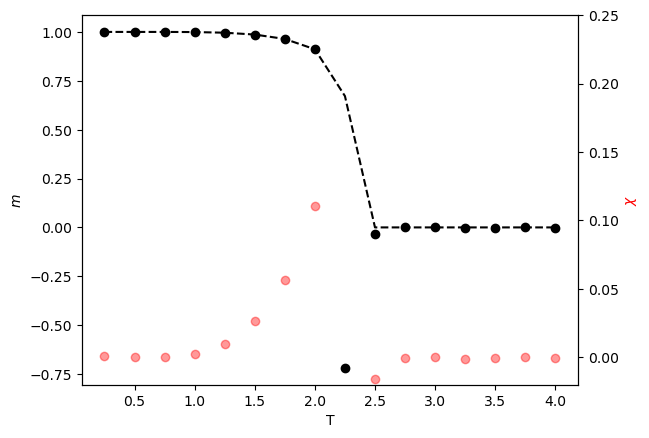

In [5]:
T_m_m2 = np.loadtxt('srednie_w_czasie.dat').transpose()

def m(T):
    try:
        if T == 0:
            return 0
        val = 1 - np.sinh(2/T)**(-4)
        return (val**(1/8)) if val > 0 else 0
    except:
        return 0

fig, ax = plt.subplots()

ax.plot(T_m_m2[0], T_m_m2[1], 'o', color = 'k', label =  r'$m$')
ax.plot(T_m_m2[0], [m(x) for x in T_m_m2[0]], '--', color = 'k')
ax.set_ylabel(r'$m$')

axt = ax.twinx()
axt.plot(T_m_m2[0], (T_m_m2[1] - T_m_m2[2]*T_m_m2[2])/T_m_m2[0], 'o', color = 'r', label = r'$\chi$', alpha = 0.4)
axt.set_ylabel(r'$\chi$', color = 'r')
axt.set_ylim((-0.02, 0.25))

#fig.legend(loc='upper right')
ax.set_xlabel('T')

plt.show()